# This script produces schematics of structrual connectivity with FST based on a literature review.

### The figures are dynamic, and can be changed to visualized for
species = "macaque" or "human" \
    roiCoarse = no  (shows very fine ROI selection) 
roi = "FST" or "MST" or "MT"   \
displaybrain = yes

if displaybrain == no \
    rotateon    = yes (is read only when displaybrain == no); will rotate the hierachy to be vertical \
    medial      = yes (is read only when displaybrain == no); will additionally plot medial side \
    subcortical = yes (is read only when displaybrain == no); will additionally plot subcortical

### Fine grain visualization settings can be changed in the section below
includestudies = "all"                                           # or subselection: {"tracer"}

edgeweight = "evidencecount"                                     # evidencecount, or connectivitystrength (line thickness)

edgecolor = "hierarchy"                                          # hierarchy or projection direction status (line shade/color)
                                                                    
edgedashed = "certainty"                                         # determined by uncontroversial or mixed evidence (line solid/dashed)
                                                                    
comment = "evidencesource"                                       # hovering text displays studies relevant to the affiliate node
                                                                    
remove_unconnected_nodes = 1                                     # do not display nodes w/o connections

### More details about summary logic
evidencecount: number of studies/experiments

connectivitystrength: takes a rough average of the weight found in each reference separately for forward and backward projections and then selects the max between these two

hierarchy: based largely on Felleman diagram but supported by direct tracer evidence. For nonvisual regions, hierarchichal status is inferred. Notes about this is in evidence.csv.

certainty: is by default with positive evidence of a connection unless a study explicitly tests for a connection and shows an absence.

evidencesource: abbreviations of studies used to analyze the connection or lack thereof, will reference in citations.txt.

### ROI naming conventions.

The ROIs selected were combined across several studies, which use different regional definitions. These are approximated to match those that we use here, but we add the citation to appear when hovering to provide the direct source for more exact areal boundaries in each respective method. The original names of the ROIs in each study can be found in evidence.csv.

### Notes for future

Arrows have not been added to indicate projection dirrections, but this can be an added feature. Most connections with FST in particular seem to be bidirectional. 
\
ROIs can be displayed on a more coarse scale, but this is not yet implemented.
\
Important information about the relative weight of the connection from either FST, MST, and MT to all other areas. For example, although both FST and MST might connect to parietal areas, perhaps it is moreso the case for MST. This is not captured in this data.

For the macaque FST figure, dot size represents the recorded weak/moderate/strong strength of anatomical tracer connections. Positive tracer reports are averaged within each projection direction; the larger directional category is displayed. A report of presence without a strength grade, or an absence report, does not count as weak. Areas without a graded tracer result use a fixed small dot. Fel91 remains a source for relative hierarchy, not strength.

For macaque marker colors, the existing dorsal/blue, lateral/red, and ventral/green node categories are rendered in the paper palette: light blue #B3E4F8, light red #F2B3D0, and light yellow #F9F384. Black nodes keep their neutral color.

The saved macaque FST HTML has a study selector. Check several studies to show their combined reported connections, or use Only to isolate one. Fel91 direct FST connections come from positive cells in its published Table 3, kept separately from the hierarchy citations in evidence.csv.


In [1]:
import pandas as pd
import plotly.graph_objects as go
from PIL import Image
import warnings
import matplotlib.colors as mcolors
import os
from pathlib import Path
import re
import numpy as np

# path that contains the human and macaque folders (assumes the notebook is run from the repo root)
datapath = os.getcwd()

# settings
species = "macaque"                                                # macaque or human
mainROI = "FST"                                                  # FST, MST or MT
if species == "macaque":
    includestudies = {"tracer", "DTI tractography", "inactivation"}  # "all" or array e.g., {"tracer"}
elif species == "human":
    includestudies = {"DTI tractography","rs-fMRI"}
edgeweight = "evidencecount"                                     # evidencecount, or connectivitystrength
node_size_source = "tracer_strength" if species == "macaque" and mainROI == "FST" else edgeweight
edgecolor = "hierarchy"                                          # hierarchy or projections
edgedashed = "certainty"                                         # determined by uncontroversial or mixed evidence
comment = "evidencesource"                                       # hovering text displays studies relevant to node
remove_unconnected_nodes = 1                                     # do not display nodes w/o connections

##### edge weight #####
if edgeweight == "evidencecount":
    edge_weight = {
        "one": 0.3,                 
        "multiple": 0.9          
    }
elif edgeweight == "connectivitystrength":
    edge_weight = {
        "weak": 0.3,                 
        "moderate": 0.6,                   
        "strong": 0.9
    }
    
##### possible edge colors #####
if edgecolor == "hierarchy":
    edge_color = {
        "higher": "black",                    # feedback
        "lower": "white",                 # feedforward
        "equal": "grey",                  # intermediate
        "unknown": "grey"
    }
elif edgecolor == "projections":
    edge_color = {
        "mainreceive": "white",                 # main ROI receives
        "mainsend": "black",                    # main ROI sends
        "bidirectional": "grey"                         # birectionalprojections or unknown
    }

##### possible edge dash/solid settings #####
if edgedashed == "certainty":
    edge_line = {
        "certain": "solid",                     # consensus across studies albiet strengths may differ
        "conflicting": "dash",                  # conflicting means that some studies measure presence and others absence
        "indirect": "dash"                      # not tracer [this is not implemented--just filter by includestudies]
}

##### construct updated edges.csv using criteria above (uses evidence.csv)
df_ev = pd.read_csv(f"{datapath}/{species}/evidence.csv")
df_where = pd.read_csv(f"{datapath}/{species}/nodes.csv")

# first filter out anything that is not the ROI selected
df_ev = df_ev[df_ev["Main"] == mainROI]

# exclude studies not in includestudies
if includestudies=="all":
    includestudies = df_ev["study_type"].dropna().unique()   # in case I am including all, this omite blank rows
df_ev = df_ev[df_ev["study_type"].isin(includestudies)]

# create new dataframe using IDs defined in nodes.csv
# Lookup: label -> id
label_to_id = dict(zip(df_where["label"], df_where["id"]))

# Source id for FST
source_id = label_to_id["FST"]

# calculate evidencecount (add up number of studies)
df_out = (
    df_ev[
        ~(
            (df_ev["1_main_to_affiliate_projection"].isin(["absent"]) | df_ev["1_main_to_affiliate_projection"].isna()) &
            (df_ev["2_affiliate_to_main_projection"].isin(["absent"]) | df_ev["2_affiliate_to_main_projection"].isna())
        )
    ]
    .groupby("Affiliate")
    .size()
    .reset_index(name="evidencecount")
)

# Add target id and target name
df_out["targetid"] = df_out["Affiliate"].map(label_to_id)
df_out["targetname"] = df_out["Affiliate"]
df_out["source"] = source_id   # Add source
# Add empty columns you want to fill later
df_out["connectivitystrength"] = pd.NA
df_out["hierarchy"] = pd.NA
df_out["projections"] = pd.NA
df_out["certainty"] = pd.NA
# Keep only requested headers, in order
df_out = df_out[
    [
        "source",
        "targetid",
        "targetname",
        "evidencecount",
        "projections"
    ]
]

# Optional: remove rows whose Affiliate was not found in df_where
missing_affiliates = df_out.loc[df_out["targetid"].isna(), "targetname"].unique()
if len(missing_affiliates) > 0:
    warnings.warn("Some Affiliates do not have a corresponding id")
    print(missing_affiliates)


In [2]:
# determine connectivity strength (determined by strongest projection strength irrespective of direction) [weight]

# Map projection labels to weights
proj_to_weight = {
    "weak": 1,
    "moderate": 2,
    "present": 2,
    "strong": 3,
    "broad": 3,     # treat as strong (only relevant for human)
}

# Map rounded weights back to labels
weight_to_proj = {
    1: "weak",
    2: "moderate",
    3: "strong",
}

def summarize_projection_and_certainty(series):
    # normalize strings
    s = series.astype("string").str.strip().str.lower()

    # valid weighted entries
    w = s.map(proj_to_weight)

    has_valid = w.notna().any()
    has_absent = (s == "absent").any()

    # certainty rule
    certainty = "conflicting" if (has_valid and has_absent) else "certain"

    # projection summary
    if not has_valid:
        projection = pd.NA
    else:
        avg_weight = w.mean()
        rounded_weight = int(round(avg_weight))
        rounded_weight = min(max(rounded_weight, 1), 3)
        projection = weight_to_proj[rounded_weight]

    return pd.Series({
        "projection": projection,
        "certainty": certainty
    })


def max_projection(row):
    p1 = row["projectiontoaffiliate"]
    p2 = row["projectiontomain"]

    if pd.isna(p1) and pd.isna(p2):
        return pd.NA
    if pd.isna(p1):
        return p2
    if pd.isna(p2):
        return p1

    return p1 if proj_to_weight[p1] >= proj_to_weight[p2] else p2


############# determine certainty (certain, conflicting, only indirect?) [solid]

# set to uncertain only if both projection directions are uncertain
def combine_certainty(row):
    return "conflicting" if (
        row["certaintytoaffiliate"] == "conflicting" and
        row["certaintytomain"] == "conflicting"
    ) else "certain"

# Compute per-affiliate summaries
df_proj = (
    df_ev.groupby("Affiliate")
    .apply(
        lambda g: pd.Series({
            "projectiontoaffiliate": summarize_projection_and_certainty(
                g["1_main_to_affiliate_projection"]
            )["projection"],
            "certaintytoaffiliate": summarize_projection_and_certainty(
                g["1_main_to_affiliate_projection"]
            )["certainty"],
            "projectiontomain": summarize_projection_and_certainty(
                g["2_affiliate_to_main_projection"]
            )["projection"],
            "certaintytomain": summarize_projection_and_certainty(
                g["2_affiliate_to_main_projection"]
            )["certainty"],
        }),
        include_groups=False,
    )
    .reset_index()
)

df_proj["connectivitystrength"] = df_proj.apply(max_projection, axis=1)
df_proj["certainty"] = df_proj.apply(combine_certainty, axis=1)

# Anatomical dot sizes use only explicit tracer strength labels. "Present"
# reports a connection without grading its strength, and "absent" is not weak.
# Summarize positive reports within each direction, then use the larger of
# the two directional summaries, as in the existing connectivity-strength rule.
tracer_strength_by_region = {}
tracer_absence_by_region = set()
if node_size_source == "tracer_strength":
    tracer_rows = df_ev[df_ev["study_type"] == "tracer"]
    tracer_rank = {"weak": 1, "moderate": 2, "strong": 3}
    rank_to_label = {1: "weak", 2: "moderate", 3: "strong"}
    projection_columns = (
        "1_main_to_affiliate_projection",
        "2_affiliate_to_main_projection",
    )
    for region, group in tracer_rows.groupby("Affiliate"):
        directional_scores = []
        for column in projection_columns:
            labels = group[column].astype("string").str.strip().str.lower()
            scores = labels.map(tracer_rank).dropna()
            if not scores.empty:
                directional_scores.append(int(round(scores.mean())))
            if (labels == "absent").any():
                tracer_absence_by_region.add(region)
        if directional_scores:
            tracer_strength_by_region[region] = rank_to_label[max(directional_scores)]

# merge df_out with df_proj
df_out = df_out.merge(
    df_proj,
    left_on="targetname",
    right_on="Affiliate",
    how="left"
).drop(columns="Affiliate")

In [3]:
###### determine projectionsL mainreceive mainsend or bidirectional
conditions = [
    df_out["projectiontomain"].notna() & df_out["projectiontoaffiliate"].isna(),
    df_out["projectiontomain"].isna() & df_out["projectiontoaffiliate"].notna(),
    df_out["projectiontomain"].notna() & df_out["projectiontoaffiliate"].notna(),
]

choices = [
    "mainreceive",
    "mainsend",
    "bidirectional",
]

df_out["projections"] = np.select(conditions, choices, default=pd.NA)

df_out = df_out.drop(
    columns=[
        "projectiontoaffiliate",
        "certaintytoaffiliate",
        "projectiontomain",
        "certaintytomain",
    ],
    errors="ignore"
)

###### determine hierarchy (feedforward, feedback, intermediate, uncertain) [color]

def most_frequent(series):
    s = series.astype("string").str.strip().str.lower()

    if s.dropna().empty:
        return pd.NA

    return s.value_counts().idxmax()

df_hierarchy = (
    df_ev.groupby("Affiliate")["hierarchichy_level_rel_to_main"]
    .apply(most_frequent)
    .reset_index(name="hierarchy")
)

df_out = df_out.merge(
    df_hierarchy,
    left_on="targetname",
    right_on="Affiliate",
    how="left"
).drop(columns="Affiliate")

df_out = df_out.sort_values(by="targetid")

df_out.to_csv(f"{datapath}/{species}/edges.csv", index=False)   # don’t save row indices

In [4]:
##### add column for comments per node

def clean_text(s):
    if pd.isna(s):
        return ''
    return re.sub(r'[^a-zA-Z0-9 ]', '', s)

def dedup_tokens(s):
    tokens = s.split()
    return ' '.join(dict.fromkeys(tokens))  # preserves order, removes repeats

if comment == "evidencesource":
    refs = (
        df_ev
        .assign(
            combined_ref = (
                df_ev['1_main_to_affiliate_ref'].apply(clean_text) + ' ' +
                df_ev['2_affiliate_to_main_ref'].apply(clean_text)
            ).str.strip()
        )
        .groupby('Affiliate')['combined_ref']
        .apply(lambda x: dedup_tokens(' '.join([i for i in x if i != ''])))
        .reset_index()
    )
    
    df_where = df_where.merge(
        refs,
        left_on='label',
        right_on='Affiliate',
        how='left'
    )
    
    df_where['FSTcomments'] = df_where['combined_ref']
    df_where = df_where.drop(columns=['Affiliate', 'combined_ref'])

##### remove any nodes without connections 
if remove_unconnected_nodes:
    #df_where = df_where[df_where['label'].isin(df_out['targetname'])].reset_index(drop=True)
    valid = set(df_out['targetname']) | {mainROI}
    df_where = df_where[df_where['label'].isin(valid)].reset_index(drop=True)

df_where.to_csv(f"{datapath}/{species}/selectnodes.csv", index=False)

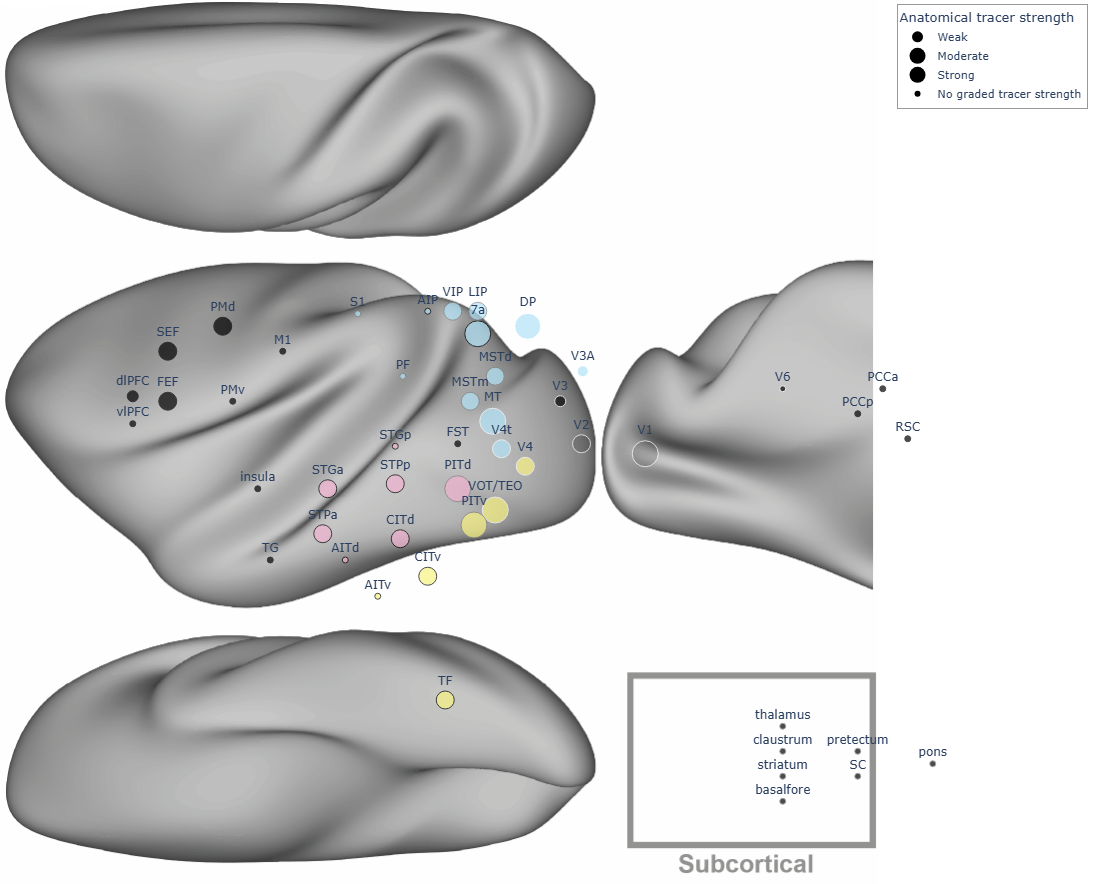

Ung84: Ungerleider, L. G., Desimone, R., Galkin, T. W., & Mishkin, M. (1984). Subcortical projections of area MT in the macaque. Journal of Comparative Neurology, 223(3), 368-386.
Bou90: Boussaoud, D., Ungerleider, L. G., & Desimone, R. (1990). Pathways for motion analysis: cortical connections of the medial superior temporal and fundus of the superior temporal visual areas in the macaque. Journal of Comparative Neurology, 296(3), 462-495.
And90: Andersen, R. A., Asanuma, C., Essick, G., & Siegel, R. M. (1990). Corticocortical connections of anatomically and physiologically defined subdivisions within the inferior parietal lobule. Journal of Comparative Neurology, 296(1), 65-113.
Fel91: Felleman, D. J., & Van Essen, D. C. (1991). Distributed hierarchical processing in the primate cerebral cortex. Cerebral Cortex, 1(1), 1-47. https://doi.org/10.1093/cercor/1.1.1
Bou92: Boussaoud, D., Desimone, R., & Ungerleider, L. G. (1992). Subcortical connections of visual areas MST and FST in macaqu

In [5]:

#def plotConnectivity(datapath, species, roi="FST", roicoarse=0, displaybrain=1, rotateon=0, medial=0, subcortical=0):

nodesOnly=1
roi="FST"
roicoarse=0
displaybrain=1
rotateon=1
medial=1
subcortical=1
    
# load image regardless because it is the basis of the coordinate system, which differs between species
if medial==1:
    imgpath = os.path.join(datapath, species, "surface_snapshots", "veryinflated_montage_nolabels_subcort.tif")
    if species=="macaque":
        shiftFactorX = 2
        shiftFactorY = 0.75
    else:
        shiftFactorX = 1.8    # these can be adjusted to shift
        shiftFactorY = 0.85
else:
    imgpath = os.path.join(datapath, species, "surface_snapshots", "veryinflated_lat_white.tif")
    # original macaque measures used figwidth/height of 900x600 instead of int(1125/2) x int(663/2).
    # to get medial==0 for macaque to recover back to normal, scale all values to account for this.
    shiftFactorX = 1
    shiftFactorY = 1

img = Image.open(imgpath)
[figheight, figwidth, nch] = np.shape(img)
figheight = int(figheight/2)
figwidth = int(figwidth/2)

#print(figwidth)
#print(figheight)

nodes_df = pd.read_csv(os.path.join(datapath, species, "selectnodes.csv"))
edges_df = pd.read_csv(os.path.join(datapath, species, "edges.csv"))

# --- Extract node info ----
ydim = int(np.floor(np.shape(img)[0]/2*shiftFactorY))
xdim = int(np.floor(np.shape(img)[1]/2*shiftFactorX))

node_x = [(x - xdim) for x in nodes_df['x'].tolist()]
node_y = [(y - ydim) * -1 for y in nodes_df['y'].tolist()]

node_labels = nodes_df['label'].tolist()
node_colors = nodes_df['color'].tolist()
if species == "macaque":
    # Match the dorsal, lateral, and ventral colors in the paper figure.
    pathway_palette = {
        "blue": "#B3E4F8",   # dorsal: light blue
        "red": "#F2B3D0",    # lateral: light red / pink
        "green": "#F9F384",  # ventral: light yellow
    }
    node_colors = [pathway_palette.get(str(color).lower(), color) for color in node_colors]
node_comments = nodes_df[f'{roi}comments'].tolist()
node_sizes  = [s * 3 for s in nodes_df['size'].tolist()]

# quick id -> index lookup
id_to_idx = {idv: i for i, idv in enumerate(nodes_df['id'].tolist())}
id_to_idx

# start with default alpha for every node
node_alpha = {idv: 1 for idv in nodes_df['id'].tolist()}
node_size = {idv: 1 for idv in nodes_df['id'].tolist()}
node_edgecolor = {idv: "black" for idv in nodes_df['id'].tolist()}

edge_traces = []

for _, row in edges_df.iterrows():
    src = row['source']
    tgt = row['targetid']

    # make uncertain nodes semi-transparent
    alpha_val = 0.2 if row[edgedashed] != "certain" else 1
    node_alpha[tgt] = alpha_val

    # in case needed (if lines are plotted)
    dash_style = edge_line.get(row[edgedashed], "solid")

    # weight
    weightPick = row[edgeweight]
    if isinstance(weightPick, (int, float)): # number of studies
        node_size[tgt] = 10 * weightPick/2
        if weightPick > 1:
            edgeIdx = "multiple"
        else:
            edgeIdx = "one"
    elif isinstance(weightPick, str): # weight of connection: strong, weak, etc.
        edgeIdx = weightPick.lower()
        node_size[tgt] = edge_weight.get(edgeIdx) # in case I need node
    # this w is for the lines    
    w = edge_weight.get(edgeIdx) # determined weights at the start of the script
    
    # color (TO DO: make this dynamic using dictionary)
    colorPick = row[edgecolor]
    edge_color_val = edge_color.get(colorPick, "grey")
    node_edgecolor[tgt] = edge_color_val
    
    i0 = id_to_idx[src]
    i1 = id_to_idx[tgt]

    x0, y0 = node_x[i0], node_y[i0]
    x1, y1 = node_x[i1], node_y[i1]

    if not nodesOnly:
        edge_traces.append(
            go.Scatter(
                x=[x0, x1],
                y=[y0, y1],
                mode="lines",
                hovertext='testing', #f"Connection: {src} → {tgt}<br>",
                hoverinfo="text",
                showlegend=False,
                line=dict(color=edge_color_val, width=w*3, dash=dash_style), #color="#777"
            )
    )

# Dot size in the macaque FST view encodes the tracer-strength summary.
# Regions lacking a graded tracer report stay visible at a fixed small size.
legend_traces = []
if node_size_source == "tracer_strength":
    size_by_strength = {"weak": 11, "moderate": 18, "strong": 26}
    unscaled_size = 6
    for i, (node_id, label) in enumerate(zip(nodes_df["id"], node_labels)):
        base_comment = "" if pd.isna(node_comments[i]) else str(node_comments[i])
        strength = tracer_strength_by_region.get(label)
        if label == mainROI:
            node_size[node_id] = unscaled_size
            strength_comment = "Seed region FST; dot size does not represent a connection"
        elif strength is None:
            node_size[node_id] = unscaled_size
            strength_comment = "No graded anatomical tracer strength"
        else:
            node_size[node_id] = size_by_strength[strength]
            strength_comment = f"Anatomical tracer strength, {mainROI} and {label}: {strength}"
        if label in tracer_absence_by_region:
            strength_comment += "; some tracer reports describe absence"
        node_comments[i] = "<br>".join(
            part for part in (base_comment, strength_comment) if part
        )

    for strength, size in size_by_strength.items():
        legend_traces.append(go.Scatter(
            x=[None], y=[None], mode="markers", name=strength.capitalize(),
            marker=dict(size=size, color="black"), hoverinfo="skip", showlegend=True
        ))
    legend_traces.append(go.Scatter(
        x=[None], y=[None], mode="markers", name="No graded tracer strength",
        marker=dict(size=unscaled_size, color="black"),
        hoverinfo="skip", showlegend=True
    ))

alphavals = [node_alpha[idv] for idv in nodes_df['id'].tolist()]

# try making semi-transparent
def to_rgba(color, alpha=0.5):
    color = color.strip()  # remove spaces
    r, g, b = mcolors.to_rgb(color)
    return f'rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, {alpha})'

if len(node_colors) != len(alphavals):
    warning("Node colors and alpha vals are not the same length. This indicates a potential issue.")

node_colors_alpha = [
    to_rgba(c, alpha=a)
    for c, a in zip(node_colors, alphavals)
]

node_size_list = [
    node_size[idv] for idv in nodes_df['id'].tolist()
]

node_edgecolor_list = [
    node_edgecolor[idv] for idv in nodes_df['id'].tolist()
]


# -------- Plot nodes --------
node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers+text',
    text=node_labels,
    textposition="top center",
    hovertext=node_comments, #f"Connection: {src} → {tgt}<br>",
    hoverinfo="text",
    showlegend=False,
    marker=dict(
        color=node_colors_alpha, # node_colors?
        size=node_size_list, #node_sizes,
        line_width=1,
        line_color=node_edgecolor_list #"black"
    )
)

fig = go.Figure(
    data=edge_traces + [node_trace] + legend_traces,
    layout=go.Layout(
        width=figwidth,
        height=figheight,
        showlegend=bool(legend_traces),
        legend=dict(
            title="Anatomical tracer strength",
            x=0.995, y=0.995, xanchor="right", yanchor="top",
            bgcolor="rgba(255,255,255,0.90)",
            bordercolor="#999", borderwidth=1, font=dict(size=11)
        ),
        hovermode='closest',
        margin=dict(b=0, l=0, r=0, t=0),
        #margin=dict(b=20, l=20, r=20, t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
    )
)

if displaybrain==1:
    fig.add_layout_image(dict(
        source=img, x=0, y=1, sizex=1, sizey=1,
        xref="paper", yref="paper", sizing="contain", layer="below"
    ))

fig.update_layout(plot_bgcolor="black")

if medial==1:
    #if species=="macaque":
    fig.update_xaxes(scaleanchor="y", scaleratio=1, range=[-50, 50])
    fig.update_yaxes(range=[-1*(figheight*2), figheight*2])
    # else:
    #     fig.update_xaxes(scaleanchor="y", scaleratio=1, range=[-100, 100])
    #     fig.update_yaxes(range=[-1*(figheight*2), figheight*2])
else:   # added this when making human
    fig.update_xaxes(scaleanchor="x", scaleratio=1, range=[-1*(figwidth), figwidth])
    fig.update_yaxes(range=[-1*(figheight), figheight])
    

fig.update_layout(
    plot_bgcolor="white",   # area inside axes
    paper_bgcolor="white"   # entire figure background
)

fig.show()

filename = f"{species}_{roi}_displaybrain{displaybrain}"
fullpath = os.path.join(datapath, filename)

fig.write_image(f"{fullpath}.pdf")
if species == "macaque" and mainROI == "FST":
    from study_filter import write_study_filter_html

    write_study_filter_html(
        fig,
        Path(f"{fullpath}_by_study.html"),
        evidence=df_ev,
        nodes_df=nodes_df,
        node_trace_index=len(edge_traces),
        edge_targets=edges_df["targetname"].astype(str).tolist() if not nodesOnly else [],
        citations_path=Path(datapath) / species / "citations.txt",
        fel91_path=Path(datapath) / species / "fel91_fst_connections.csv",
    )
    from IPython.display import HTML, display
    display(HTML(f'<a href="{filename}_by_study.html" target="_blank">Open the interactive study selector</a>'))
else:
    fig.write_html(f"{fullpath}.html")

refpath = os.path.join(datapath, species, "citations.txt")
with open(refpath, "r") as f:
    citations = f.read()
    print(citations)
